<a href="https://colab.research.google.com/github/fmensah1/ddos-research-project/blob/main/DDoSbasic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing dataset


In [ ]:
dataset = pd.read_csv('ACI-IoT-2023.csv')
dataset.columns = dataset.columns.str.strip()


Drop columns

In [ ]:
dataset = dataset.drop(
    columns=["Flow ID", "Src IP", "Dst IP", "Timestamp", "Connection Type"],
    errors="ignore"
)

Define our target and features

In [ ]:
y = dataset["Label"]
X = dataset.drop(columns=["Label"])

Correlation matrix

In [ ]:
num_X = X.select_dtypes(include="number")
num_X = num_X.replace([np.inf, -np.inf], np.nan) # Replace infinite values with NaN
num_X = num_X.dropna() # Remove rows with NaN values
corr = num_X.corr(method="pearson")
print("corr shape:", corr.shape)

corr shape: (79, 79)


heat map


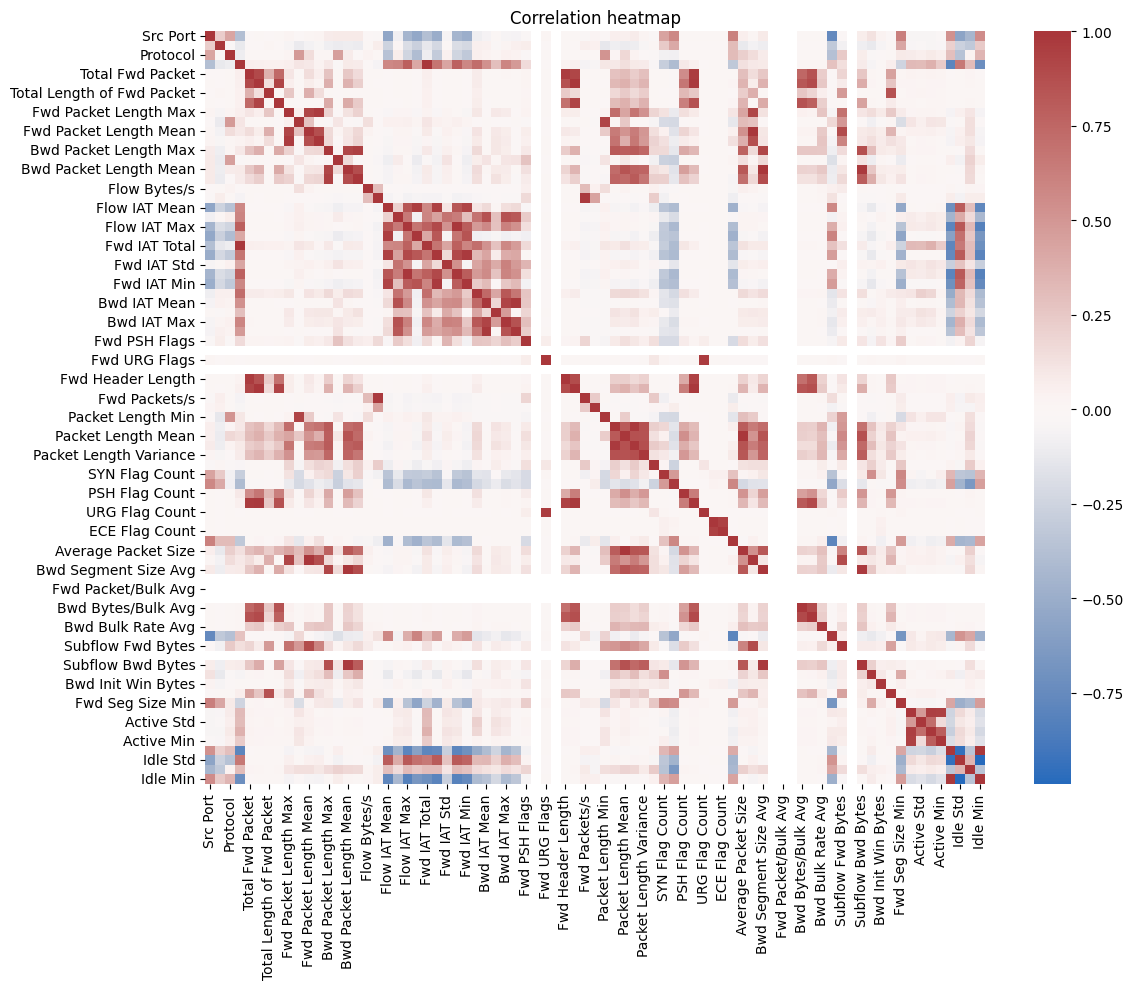

In [ ]:
num_X = num_X.drop(columns=["Src Port", "Dst Port", "Protocol"], errors="ignore")
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Correlation ratio

Feature ↔ target correlation shape: (73, 12)
                  ARP Spoofing    Benign  DNS Flood  Dictionary Attack  \
Src Port             -0.003183 -0.042227   0.085830          -0.007841   
Dst Port             -0.001520 -0.124898  -0.149617          -0.008405   
Protocol             -0.002636  0.435361   0.427607          -0.005432   
Flow Duration        -0.000885  0.284948  -0.048321           0.006429   
Total Fwd Packet     -0.000032  0.036284  -0.004445           0.000766   

                  ICMP Flood   OS Scan  Ping Sweep  Port Scan  SYN Flood  \
Src Port           -0.747486  0.166975    0.041978   0.534165  -0.168071   
Dst Port           -0.356894 -0.060577   -0.082467   0.543882   0.082384   
Protocol           -0.618991 -0.014429   -0.021980  -0.048142  -0.009414   
Flow Duration       0.227305 -0.075423   -0.109702  -0.328242  -0.017576   
Total Fwd Packet   -0.008986 -0.004254   -0.006101  -0.018077  -0.001468   

                  Slowloris  UDP Flood  Vulnerability

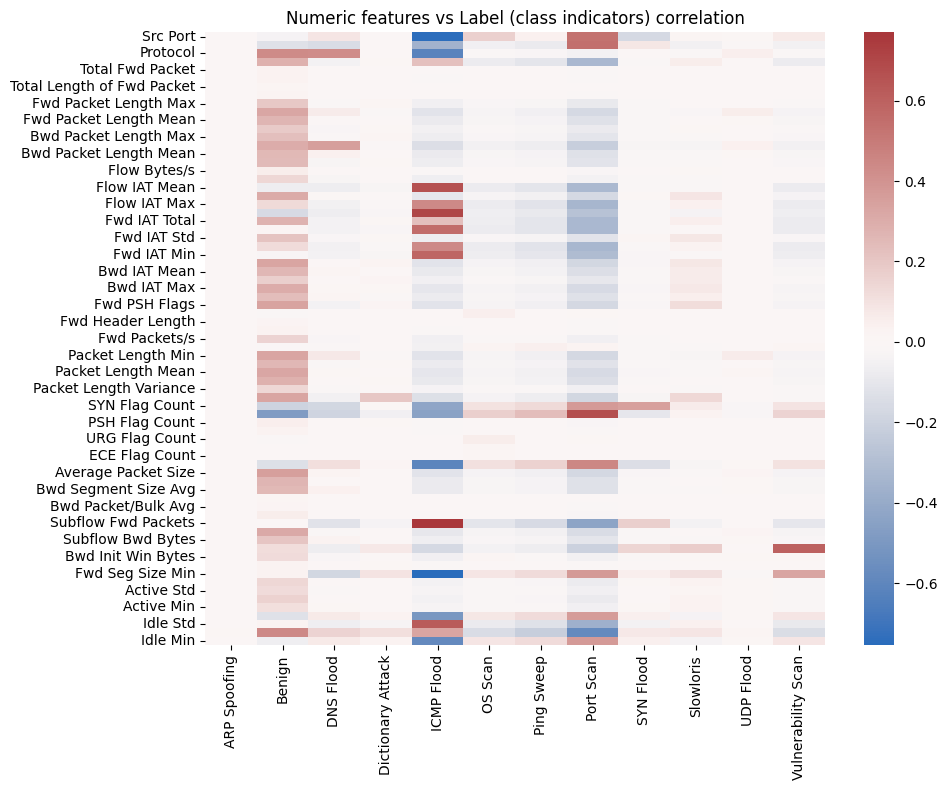

In [26]:
y_dum = pd.get_dummies(y)  # one column per class

# Drop columns from num_X with zero variance
num_X_no_zero_variance = num_X.loc[:, num_X.std() != 0]


# Correlation of each numeric feature with each class indicator
feat_target_corr = pd.DataFrame({
    cls: num_X_no_zero_variance.corrwith(y_dum[cls].astype("float32"))
    for cls in y_dum.columns
})

print("Feature ↔ target correlation shape:", feat_target_corr.shape)
print(feat_target_corr.head())

plt.figure(figsize=(10, 8))
sns.heatmap(feat_target_corr, cmap="vlag", center=0)
plt.title("Numeric features vs Label (class indicators) correlation")
plt.tight_layout()
plt.show()